In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

np.random.seed(42)

rows = 12000

data = {
    "Patient_ID": range(1, rows+1),
    "Pregnancies": np.random.randint(0, 11, rows),
    "Glucose": np.random.randint(70, 220, rows),
    "BloodPressure": np.random.randint(60, 110, rows),
    "BP_Category": np.random.choice(["Low", "Normal", "High"], rows),
    "SkinThickness": np.random.randint(10, 60, rows),
    "Insulin": np.random.randint(15, 350, rows),
    "BMI": np.round(np.random.uniform(16.0, 50.0, rows), 1),
    "Age": np.random.randint(18, 80, rows),
    "HeartDisease": np.random.choice([0, 1], rows),
    "FamilyHistory": np.random.choice([0, 1], rows),
    "Smoking": np.random.choice([0, 1], rows),
    "AlcoholIntake": np.random.choice([0, 1, 2], rows),
    "DietScore": np.random.randint(1, 10, rows),
    "FrequentUrination": np.random.choice([0, 1], rows),
    "ExcessiveThirst": np.random.choice([0, 1], rows),
    "Fatigue": np.random.choice([0, 1], rows),
    "BlurredVision": np.random.choice([0, 1], rows)
}

df = pd.DataFrame(data)
df.head()

,Patient_ID,Pregnancies,Glucose,BloodPressure,BP_Category,SkinThickness,Insulin,BMI,Age,HeartDisease,FamilyHistory,Smoking,AlcoholIntake,DietScore,FrequentUrination,ExcessiveThirst,Fatigue,BlurredVision
0,1,6,115,97,High,44,345,32.0,41,1,0,1,1,4,0,0,1,0
1,2,3,84,104,Normal,26,261,23.2,21,0,1,0,0,1,0,0,1,1
2,3,10,199,98,High,35,246,45.0,64,1,1,1,2,9,1,1,1,1
3,4,7,130,60,Normal,30,306,39.1,67,0,0,1,2,5,0,0,1,1
4,5,4,184,81,Low,21,184,19.2,52,0,1,1,0,9,1,0,0,1


In [34]:
# Adding noise to simulate real world data
df["Glucose"] += np.random.normal(0, 25, rows)
df["BMI"] += np.random.normal(0, 3, rows)
df["Insulin"] += np.random.normal(0, 40, rows)
df["BloodPressure"] += np.random.normal(0, 15, rows)

In [35]:
# Introducing outliers 
for col in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
    outlier_idx = np.random.choice(df.index, size=40)
    df[col] = df[col].astype(float)
    df.loc[outlier_idx, col] *= np.random.uniform(1.5, 2.2)

In [36]:
# Increasing missing values
for col in df.columns:
    if col != "Patient_ID":
        df.loc[df.sample(frac=0.08).index, col] = np.nan

In [37]:
# Converting BMI into categories
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df["BMI_Category"] = df["BMI"].apply(bmi_category)


df.drop("BMI", axis=1, inplace=True)

In [38]:
# Creating target variable 
def calculate_outcome(row):
    score = 0
    if row["Glucose"] > 150: score += 2
    if row["Age"] > 50: score += 1
    if row["BloodPressure"] > 90: score += 1
    if row["Insulin"] > 200: score += 1
    if row["HeartDisease"] == 1: score += 1
    if row["FamilyHistory"] == 1: score += 2
    if row["FrequentUrination"] == 1: score += 1
    if row["ExcessiveThirst"] == 1: score += 1

    
    score += np.random.randint(-2, 3)

    return 1 if score >= 4 else 0

df["Outcome"] = df.apply(calculate_outcome, axis=1)

In [39]:
# Fill missing numeric values with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Fill categorical missing values with mode
df.fillna(df.mode().iloc[0], inplace=True)

In [40]:
# Convert categorical columns to numeric
df = pd.get_dummies(df, columns=["BP_Category", "BMI_Category"], drop_first=True)

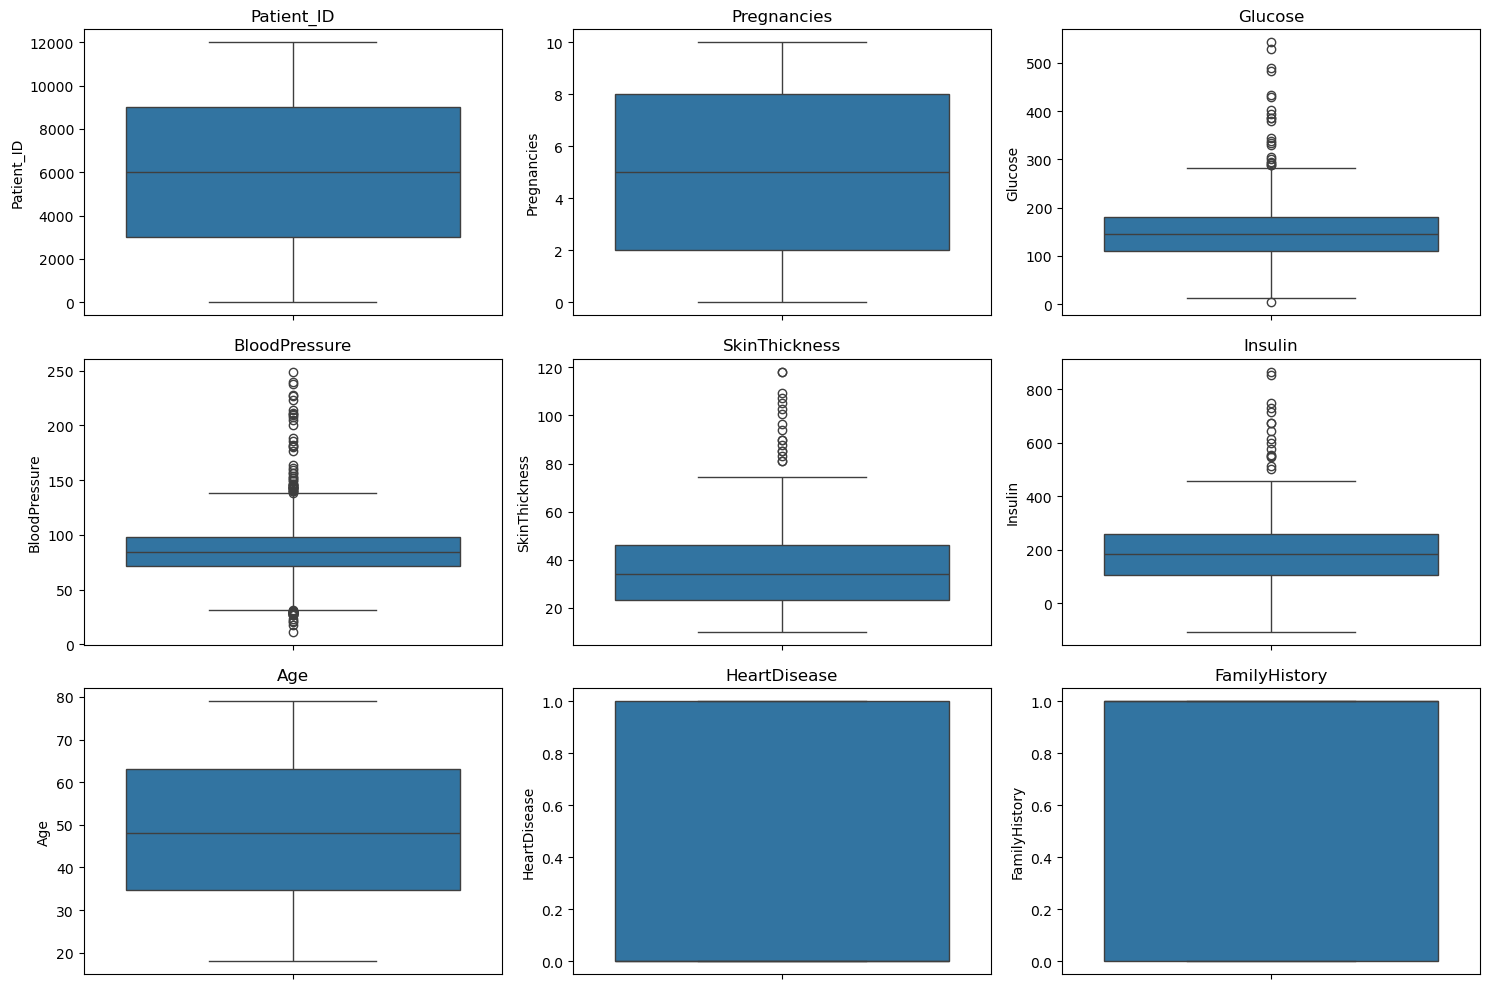

In [41]:
# Visualize distributions
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols[:9]):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [42]:
#relaxed IQR (keep some outliers)
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[num_cols] < (Q1 - 2.5 * IQR)) |
         (df[num_cols] > (Q3 + 2.5 * IQR))).any(axis=1)]

print("After outlier removal:", df.shape)

After outlier removal: (11957, 22)


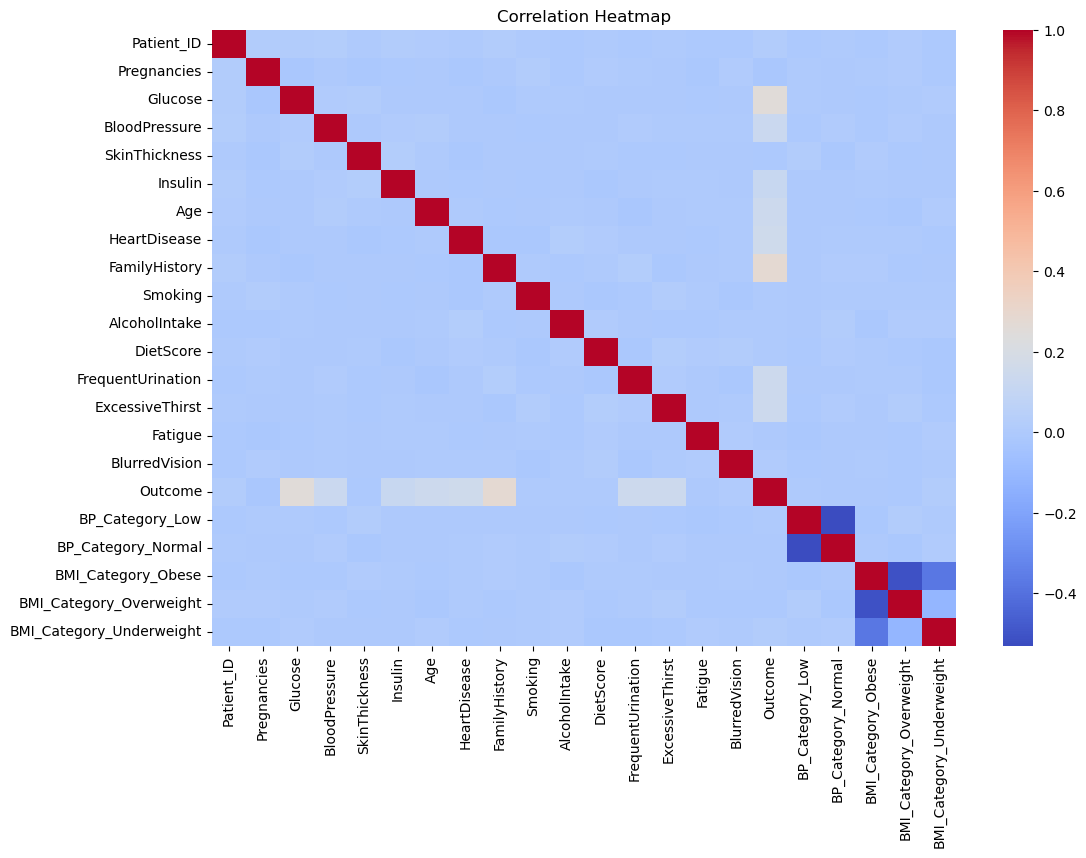

In [43]:
# Visualize correlations
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [44]:
corr = df.corr()["Outcome"].abs().sort_values(ascending=False)
selected_features = corr[1:10].index

print("Selected Features:", selected_features)

Selected Features: Index(['FamilyHistory', 'Glucose', 'HeartDisease', 'Age', 'ExcessiveThirst',
       'FrequentUrination', 'BloodPressure', 'Insulin', 'Pregnancies'],
      dtype='object')


In [45]:
# Saving dataset
df.to_csv("db_risk.csv", index=False)

In [46]:
X = df[selected_features]
y = df["Outcome"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [47]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [50]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)
import matplotlib.pyplot as plt

🔹 Random Forest Evaluation
Accuracy: 0.7366220735785953
Precision: 0.7836508912108174
Recall: 0.8209916291049582
F1 Score: 0.8018867924528302
ROC-AUC: 0.8083121061392959

Confusion Matrix:
 [[ 487  352]
 [ 278 1275]]

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.58      0.61       839
           1       0.78      0.82      0.80      1553

    accuracy                           0.74      2392
   macro avg       0.71      0.70      0.70      2392
weighted avg       0.73      0.74      0.73      2392



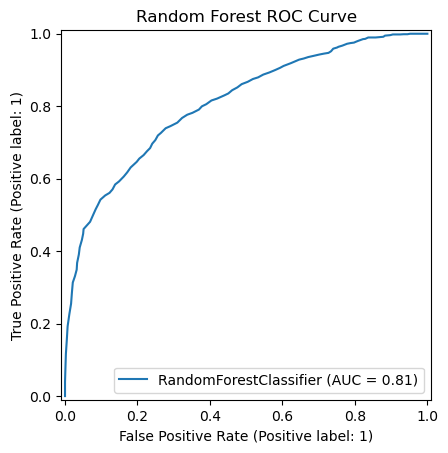

In [51]:
# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Metrics
print("🔹 Random Forest Evaluation")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# ROC Curve
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("Random Forest ROC Curve")
plt.show()

🔹 Logistic Regression Evaluation
Accuracy: 0.7265886287625418
Precision: 0.76996996996997
Recall: 0.8254990341274951
F1 Score: 0.7967681789931634
ROC-AUC: 0.7912395325438019

Confusion Matrix:
 [[ 456  383]
 [ 271 1282]]

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.54      0.58       839
           1       0.77      0.83      0.80      1553

    accuracy                           0.73      2392
   macro avg       0.70      0.68      0.69      2392
weighted avg       0.72      0.73      0.72      2392



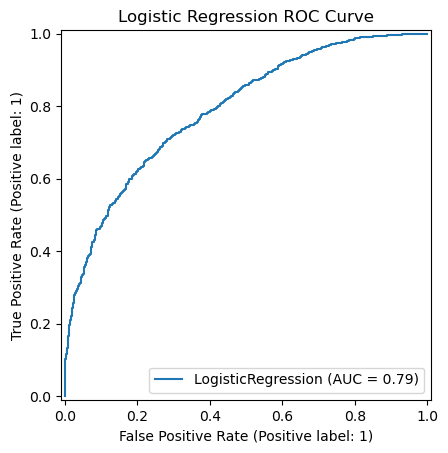

In [52]:
# Predictions
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Metrics
print("🔹 Logistic Regression Evaluation")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

# ROC Curve
RocCurveDisplay.from_estimator(lr_model, X_test, y_test)
plt.title("Logistic Regression ROC Curve")
plt.show()

🔹 KNN Evaluation
Accuracy: 0.7148829431438127
Precision: 0.7706650093225605
Recall: 0.798454603992273
F1 Score: 0.7843137254901961
ROC-AUC: 0.749325193961167

Confusion Matrix:
 [[ 470  369]
 [ 313 1240]]

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.56      0.58       839
           1       0.77      0.80      0.78      1553

    accuracy                           0.71      2392
   macro avg       0.69      0.68      0.68      2392
weighted avg       0.71      0.71      0.71      2392



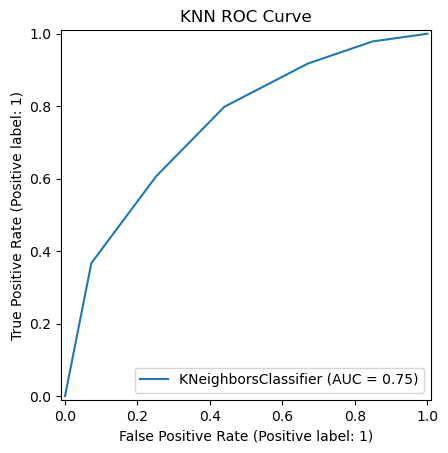

In [53]:
# Predictions
y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

# Metrics
print("🔹 KNN Evaluation")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

# ROC Curve
RocCurveDisplay.from_estimator(knn_model, X_test, y_test)
plt.title("KNN ROC Curve")
plt.show()

In [54]:
# Compare models in a single table
import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "KNN"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_knn)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.736622,0.783651,0.820992,0.801887,0.808312
1,Logistic Regression,0.726589,0.769970,0.825499,0.796768,0.791240
2,KNN,0.714883,0.770665,0.798455,0.784314,0.749325
